<a href="https://colab.research.google.com/github/HoFangHuy/AI/blob/main/helpme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
from ultralytics import YOLO
from PIL import Image
import os

# Load model YOLOv8n
model = YOLO("yolov8n.pt")

# Hàm detect và crop
def detect_and_crop(image_path, output_dir="crops"):
    os.makedirs(output_dir, exist_ok=True)

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    results = model(source=image_path)[0]

    count = 0
    for i, box in enumerate(results.boxes):
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Kiểm tra xem toạ độ có hợp lệ không
        if x2 > x1 and y2 > y1 and 0 <= x1 < x2 <= width and 0 <= y1 < y2 <= height:
            cropped = image.crop((x1, y1, x2, y2))
            cropped = cropped.resize((224, 224))
            cropped.save(f"{output_dir}/crop_{count}.jpg")
            count += 1
        else:
            print(f"⚠️ Bỏ qua bbox không hợp lệ: {x1}, {y1}, {x2}, {y2}")

    print(f"✅ Đã crop {count} đối tượng hợp lệ vào thư mục `{output_dir}`")


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Thông số
img_size = (224, 224)
#batch_size = 32
data_path = '/content/drive/MyDrive/Data AI'

# Tiền xử lý dữ liệu
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    #batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    #batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_gen, validation_data=val_gen, epochs=10)


Found 1019 images belonging to 9 classes.
Found 249 images belonging to 9 classes.
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 275s 8s/step - accuracy: 0.2024 - loss: 2.7486 - val_accuracy: 0.1566 - val_loss: 2.8131
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 318s 8s/step - accuracy: 0.3367 - loss: 2.0178 - val_accuracy: 0.1566 - val_loss: 11.7640
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 258s 8s/step - accuracy: 0.3640 - loss: 1.7730 - val_accuracy: 0.1566 - val_loss: 10.2888
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 261s 8s/step - accuracy: 0.4342 - loss: 1.6465 - val_accuracy: 0.1566 - val_loss: 14.8688
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 264s 8s/step - accuracy: 0.4329 - loss: 1.6072 - val_accuracy: 0.1566 - val_loss: 25.2316
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 259s 8s/step - accuracy: 0.4813 - loss: 1.4728 - val_accuracy: 0.1566 - val_loss: 24.9960
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 270s 8s/step - accuracy: 0.4978 - loss: 1.4712 - val_accuracy: 0.1566 - val_loss: 29.2068
Epoch 8/10
32/32 ━━━━━

In [8]:
model.save('my_cnn_model.h5')

In [17]:
import cv2
import numpy as np
import os

# Danh sách tên món ăn và giá (ví dụ)
class_names = ["Ca hu kho", "Canh cai", "Canh chua", "Dau hu sot ca", "Ga chien", "Rau muong xao toi", "Thit kho", "Thit kho trung", "Trung chien"]
prices = {"Ca hu kho": 12000, "Canh cai": 7000, "Canh chua": 7000, "Dau hu sot ca": 12000, "Ga chien": 12000, "Rau muong xao toi": 5000, "Thit kho": 8000, "Thit kho trung": 8000, "Trung chien": 5000}
from tensorflow.keras.models import load_model

model_cnn = load_model("/content/my_cnn_model.h5")  # đổi tên file nếu khác


def recognize_and_bill(crop_dir):
    total = 0
    print("=== HÓA ĐƠN MÓN ĂN ===")

    for filename in os.listdir(crop_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            path = os.path.join(crop_dir, filename)
            img = cv2.imread(path)

            # ✅ Kiểm tra ảnh có đọc được không
            if img is None:
                print(f"⚠️ Không đọc được ảnh: {filename}, bỏ qua.")
                continue

            img = cv2.resize(img, (224, 224))  # Resize cho model CNN
            img = img / 255.0
            img = np.expand_dims(img, axis=0)

            # Dự đoán
            prediction = model_cnn.predict(img)
            class_id = np.argmax(prediction)
            class_name = class_names[class_id]
            price = prices[class_name]

            print(f"{class_name}: {price:,} VND")
            total += price

    print(f"==> TỔNG CỘNG: {total:,} VND")


In [18]:
image_path = "/content/z6582833044510_7474a1a2b289d32c1ae3075e496449cb.jpg"  # Đường dẫn ảnh khay cơm
detect_and_crop(image_path, output_dir="crops")
recognize_and_bill("crops")


image 1/1 /content/z6582833044510_7474a1a2b289d32c1ae3075e496449cb.jpg: 640x480 4 bowls, 2 dining tables, 180.8ms
Speed: 4.4ms preprocess, 180.8ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)
✅ Đã crop 6 đối tượng hợp lệ vào thư mục `crops`
=== HÓA ĐƠN MÓN ĂN ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
Trung chien: 5,000 VND
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Trung chien: 5,000 VND
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Trung chien: 5,000 VND
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Trung chien: 5,000 VND
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Ga chien: 12,000 VND
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Trung chien: 5,000 VND
==> TỔNG CỘNG: 37,000 VND


In [19]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image

def display_results(crop_dir="crops"):
    plt.figure(figsize=(12, 6))
    i = 1

    for filename in os.listdir(crop_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img_path = os.path.join(crop_dir, filename)
            img = image.load_img(img_path, target_size=(224, 224))  # Resize đúng input CNN
            img_array = image.img_to_array(img)
            img_array = img_array / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Dự đoán món ăn
            prediction = model_cnn.predict(img_array)
            class_id = np.argmax(prediction)
            class_name = class_names[class_id]

            # Đọc ảnh gốc để hiển thị
            img_display = cv2.imread(img_path)
            img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

            # Vẽ lên ảnh
            plt.subplot(2, 3, i)  # Thay đổi số ảnh nếu cần
            plt.imshow(img_display)
            plt.title(class_name)
            plt.axis('off')
            i += 1

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


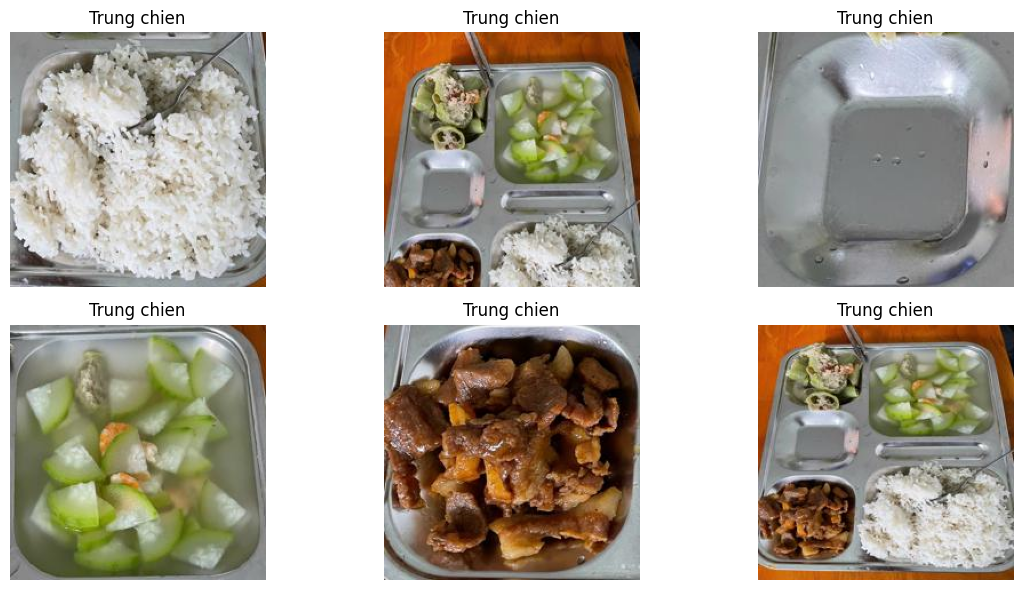

In [20]:
display_results("crops")
